In [1]:
import pandas as pd
Data=pd.read_csv("Nassau Candy Distributor.csv")

Data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


# Data Cleaning and Validation


# Validate Cost and Sales Values


In [19]:
# First remove $ symbol and commas from Sales
Data["Sales"]=Data["Sales"].astype(str).str.replace("$","",regex=False).str.replace(",","",regex=False)

# Convert cleaned Sales values into numeric form
Data["Sales"]=pd.to_numeric(Data["Sales"],errors="coerce")

# First remove $ symbol and commas from Cost
Data["Cost"]=Data["Cost"].astype(str).str.replace("$","",regex=False).str.replace(",","",regex=False)

# Convert cleaned Cost values into numeric form
Data["Cost"]=pd.to_numeric(Data["Cost"],errors="coerce")

# Show rows where Sales or Cost could not be converted
invalid_values=Data[Data["Sales"].isna() | Data["Cost"].isna()]
print(invalid_values)


# Checking for sales and cost values that are greater than zero
valid_data = Data[(Data["Sales"] > 0) & (Data["Cost"] >= 0)]
print(valid_data)

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost, Profit, Gross Margin, profit_per_unit, Gross_Profit, Gross_Margin_%, Profit_per_Unit_%, Profit_Contribution_%]
Index: []

[0 rows x 25 columns]
       Row ID                      Order ID  Order Date   Ship Date  \
0           1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1           2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2           3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3           4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4           5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   
...       ...                           ...         ...         ...   
10189   10190  US-2024-143259-CHO-MIL-31000  30-12-2025  26-06-2030   
10190   10191  US-2024-115427-CHO-NUT-13000  30-12-2025  26-06-2030 

# Remove zero-sales or invalid profit records


In [23]:
# Calculate Profit only after cleaning values
Data["Profit"]=Data["Sales"]-Data["Cost"]
Data.head(20)

#Removing Zero and negative sales
Data_clean=Data[Data["Sales"]>0]

# Removing Invalid profit
Data_clean=Data_clean.dropna(subset=["Profit"])
result = (Data_clean["Sales"] != 0).sum()
print(f"Number of rows with non-zero sales: {result}")
result = (Data_clean["Sales"] == 0).sum()
print(f"Number of rows with zero sales: {result}")

# No. of rows removed due to zero or negative sales
removed_rows=len(Data)-len(Data_clean)
print(f"Number of rows removed due to zero or negative sales: {removed_rows}")

Number of rows with non-zero sales: 10194
Number of rows with zero sales: 0
Number of rows removed due to zero or negative sales: 0


# Handle missing unit values

In [ ]:
# Calculate median of Units and fill missing values with median
medians_units=Data["Units"].median()
Data["Units"]=Data["Units"].fillna(medians_units)

# Check for rows with zero units and invalid units
print(f'Number of rows with zero units: {Data[Data["Units"]==0].shape[0]}')
invalid_units = Data[(Data["Sales"] > 0) & (Data["Units"] <= 0)]
print(f'Number of rows with invalid units: {invalid_units.shape[0]}')

Number of rows with zero units: 0
Number of rows with invalid units: 0


# Standardize product and division labels


In [ ]:
# Standardizing Division and Product Name columns
Data["Division"]=Data["Division"].astype(str).str.strip().str.title()
Data["Product Name"]=Data["Product Name"].astype(str).str.strip().str.title()

# Mapping for Division 
division_mapping={
    "Confectionary":"Confectionery",
    "Confect":"Confectionery",
    "Snack":"Snacks",
    "Beverage":"Beverages"
}
# Replacing the values in Division column based on mapping
Data["Division"]=Data["Division"].replace(division_mapping)

# Mapping for Product Name
product_mapping={
    "Choclate":"Chocolate",
    "Chococ Bar": "Chocolate Bar",
    "CandyBox":"Candy Box",
    "Candybox": "Candy Box"
}

# Replacing the values in Product Name column based on mapping
Data["Product Name"]=Data["Product Name"].replace(product_mapping)

# Profitability Metric Calculation For each product

In [ ]:
# Calculate Gross Margin Percentage
Data["Gross Margin"]=(Data["Profit"]/Data["Sales"])*100

# Profit per unit
Data["profit_per_unit"]=Data["Profit"]/Data["Units"]

# Replace infinite values caused by zero units with NaN
Data["profit_per_unit"]=Data["profit_per_unit"].replace([float("inf"),float("-inf")],pd.NA)

# Product Profitability
product_profitability=Data.groupby("Product Name").agg(
    Total_sales=("Sales","sum"),
    Total_units=("Units","sum"),
    Total_cost=("Cost","sum")
).reset_index()

# Calculate total profit
product_profitability["Gross_Profit"] = (
    product_profitability["Total_sales"] -
    product_profitability["Total_cost"]
)

# Calculate gross margin percentage
product_profitability["Gross_Margin_%"] = (
    product_profitability["Gross_Profit"] /
    product_profitability["Total_sales"]
) * 100

# Calculate profit per unit
product_profitability["Profit_per_Unit"] = (
    product_profitability["Gross_Profit"] /
    product_profitability["Total_units"]
)

# Calculate total profit contribution
Total_profit = product_profitability["Gross_Profit"].sum()

product_profitability["Profit_Contribution_%"] = (
    product_profitability["Gross_Profit"] /
    Total_profit
) * 100
print(product_profitability)

                         Product Name  Total_sales  Total_units  Total_cost  \
0              Everlasting gobstopper       130.00           13       26.00   
1                Fizzy lifting drinks        78.75           21       31.50   
2                             Fun dip        12.00            8        7.20   
3                         Hair toffee        76.50           17       17.00   
4                           Kazookles      1205.75          371     1113.00   
5                         Laffy taffy        53.73           27       20.25   
6                  Lickable wallpaper      7860.00          393     3930.00   
7                               Nerds        15.00           10        8.00   
8                           Sweetarts        61.50           41       32.80   
9           Wonka bar - fudge mallows     24890.40         6914     8296.80   
10         Wonka bar - milk chocolate     26867.75         8267     9424.38   
11  Wonka bar - nutty crunch surprise     23574.95  

# Product-Level Profitability Analysis

In [ ]:
# Rank products by: Gross profit

# Gross Profit earned by each product
product_profitability["Gross_Profit"] = (
    product_profitability["Total_sales"] -
    product_profitability["Total_cost"]
)

product_profitability["Gross_profit_rank"]=product_profitability["Gross_Profit"].rank(ascending=False,method="dense").astype(int)

rank_by_profit=product_profitability.sort_values(by="Gross_Profit",ascending=False)
print(rank_by_profit[["Product Name","Total_sales","Gross_Profit","Gross_profit_rank"]])

# Rank products by: Gross margin

# Gross margin earned by each product
product_profitability["Gross_Margin_%"]=(
    product_profitability["Gross_Profit"]/
    product_profitability["Total_sales"]*100)

product_profitability["Gross_Margin_rank"]=product_profitability["Gross_Margin_%"].rank(ascending=False,method="dense").astype(int)

rank_by_profit=product_profitability.sort_values(by="Gross_Margin_%",ascending=False)
print(rank_by_profit[["Product Name","Total_sales","Gross_Profit","Gross_Margin_%","Gross_Margin_rank"]])

# High-Profit / High-Margin Products

# Calculate benchmark values
profit_median=product_profitability["Gross_Profit"].median()
margin_median=product_profitability["Gross_Margin_%"].median()

# Identify products that are high in both profit and margin
high_profit_and_margin = product_profitability[
    (product_profitability["Gross_Profit"] >= profit_median) &
    (product_profitability["Gross_Margin_%"] >= margin_median)
]
print(high_profit_and_margin[
    ["Product Name","Gross_Profit","Gross_Margin_%"]
])

# Identify High-Sales / Low-Margin Products
sales_median=product_profitability["Total_sales"].median()
High_Sales_Low_Margin=product_profitability[
    (product_profitability["Total_sales"]>=sales_median) &
    (product_profitability["Gross_Margin_%"]<margin_median)
]
print(High_Sales_Low_Margin[
      ["Product Name","Total_sales","Gross_Profit","Gross_Margin_%"]
      ])

# Low-Sales / Low-Profit Products
Low_sales_Low_profit=product_profitability[
    (product_profitability["Total_sales"]<sales_median) &
    (product_profitability["Gross_Profit"]<profit_median)
]
print(Low_sales_Low_profit[
    ["Product Name","Total_sales","Gross_Profit","Gross_Margin_%"]
])


                         Product Name  Total_sales  Gross_Profit  \
13     Wonka bar -scrumdiddlyumptious     27874.80      19357.50   
12  Wonka bar - triple dazzle caramel     28485.00      18610.20   
10         Wonka bar - milk chocolate     26867.75      17443.37   
11  Wonka bar - nutty crunch surprise     23574.95      16819.95   
9           Wonka bar - fudge mallows     24890.40      16593.60   
6                  Lickable wallpaper      7860.00       3930.00   
14                          Wonka gum       597.50        310.70   
0              Everlasting gobstopper       130.00        104.00   
4                           Kazookles      1205.75         92.75   
3                         Hair toffee        76.50         59.50   
1                Fizzy lifting drinks        78.75         47.25   
5                         Laffy taffy        53.73         33.48   
8                           Sweetarts        61.50         28.70   
7                               Nerds        15.

# Division-Level Performance Analysis

In [27]:
# Aggregate metrics by Division
Division_profitability=Data.groupby("Division").agg(
    Total_sales=("Sales","sum"),
    Total_cost=("Cost","sum"),
    Total_units=("Units","sum")
).reset_index()

# Calculate Gross Profit by Division
Division_profitability["Gross_Profit"]=Division_profitability["Total_sales"]-Division_profitability["Total_cost"]
print(Division_profitability)

# Calculate Average Margin by Division
# Calculate Gross Margin Percentage by Division
Division_profitability["Gross_Margin"]=(Division_profitability["Gross_Profit"]/Division_profitability["Total_sales"]*100)

# Round off Gross Margin upto 2 decimal
Division_profitability["Gross_Margin"]=Division_profitability["Gross_Margin"].round(2)
print(Division_profitability[
    ["Division","Total_sales","Gross_Profit","Gross_Margin"]
    ])

#  Revenue vs Profit Imbalance
# Total Sales and Profit of all divsion
overall_sales=Division_profitability["Total_sales"].sum()
overall_profit=Division_profitability["Gross_Profit"].sum()

# Revenue Contribution of each division 
Division_profitability["Revenue_Contribution"]=(Division_profitability["Total_sales"]/overall_sales)*100

# Profit Contribution of each division 
Division_profitability["Profit_Contribution"]=(Division_profitability["Gross_Profit"]/overall_profit)*100

# Difference between revenue share and profit share
Division_profitability["revenue_profit_gap"]=(Division_profitability["Revenue_Contribution"]-Division_profitability["Profit_Contribution"])

print(Division_profitability[
    ["Division","Revenue_Contribution","Profit_Contribution","revenue_profit_gap"]
])

# Identify divisions with: Strong financial efficiency
# Calculate median gross margin across all divisions
Division_margin_median=Division_profitability["Gross_Margin"].median()

# Strong divisions have above-average margin and profit share greater than or equal to their revenue share
Strong_division=Division_profitability[
    (Division_profitability["Gross_Margin"]>=Division_margin_median) &
    (Division_profitability["revenue_profit_gap"]<=0)
]
print(Strong_division[
    ["Division","Total_sales","Gross_Profit","Gross_Margin","revenue_profit_gap"]
])

# Identify Divisions with Structural Margin Issues
# Divisions with low margin and more revenue share than profit share
structural_margin_issues = Division_profitability[
    (Division_profitability["Gross_Margin"] < Division_margin_median) &
    (Division_profitability["revenue_profit_gap"] > 0)
]

print(structural_margin_issues[
    ["Division", "Total_sales", "Gross_Profit",
     "Gross_Margin", "revenue_profit_gap"]
])


    Division  Total_sales  Total_cost  Total_units  Gross_Profit
0  Chocolate    131692.90    42868.28        37275      88824.62
1      Other      9663.25     5329.80         1242       4333.45
2      Sugar       427.48      142.75          137        284.73
    Division  Total_sales  Gross_Profit  Gross_Margin
0  Chocolate    131692.90      88824.62         67.45
1      Other      9663.25       4333.45         44.84
2      Sugar       427.48        284.73         66.61
    Division  Revenue_Contribution  Profit_Contribution  revenue_profit_gap
0  Chocolate             92.883008            95.057747           -2.174739
1      Other              6.815491             4.637543            2.177948
2      Sugar              0.301502             0.304710           -0.003209
    Division  Total_sales  Gross_Profit  Gross_Margin  revenue_profit_gap
0  Chocolate    131692.90      88824.62         67.45           -2.174739
2      Sugar       427.48        284.73         66.61           -0.00320

# Profit Concentration (Pareto) Analysis

#  Determine % of products contributing: 80% of revenue contribution


In [9]:
product_revenue=Data.groupby("Product Name").agg(
    Total_sales=("Sales","sum")
).reset_index()

# Sorting values from highest to lowest
product_revenue=product_revenue.sort_values(
    by="Total_sales",
    ascending=False
).reset_index(drop=True)

#  Calculate total revenue of all products
product_revenue["Total_Revenue"] =product_revenue["Total_sales"].sum()

# Calculate cummalative revenue
product_revenue["Cumulative_Revenue"]=product_revenue["Total_sales"].cumsum()
product_revenue

#  Calculate cummalative revenue %
product_revenue["Cumulative_Revenue_%"]=(product_revenue["Cumulative_Revenue"]/product_revenue["Total_Revenue"]*100)

# First product that reach to 80
first_80_revenue_index=product_revenue[
    product_revenue["Cumulative_Revenue_%"]>=80
].index[0]

# Select all products from rank 1 up to the product
# that reaches or crosses 80% revenue.
top_revenue_product=product_revenue.loc[:first_80_revenue_index]
top_revenue_product

# Total no. of products
total_products=len(product_revenue)

# total no. of top revenue product
product_for_80_revenue=len(top_revenue_product)

percentage_for_product_80_revenue=(product_for_80_revenue/total_products)*100

# Display Result

print("Products Contributing at least 80% of revenue :",top_revenue_product)
print("Total Products :",total_products)
print("Product needed for 80% revenue",product_for_80_revenue)
print("Percentage for product contributing to 80% of product revenue :",round(percentage_for_product_80_revenue,2))

Products Contributing at least 80% of revenue :                         Product Name  Total_sales  Total_Revenue  \
0  Wonka bar - triple dazzle caramel     28485.00      141783.63   
1     Wonka bar -scrumdiddlyumptious     27874.80      141783.63   
2         Wonka bar - milk chocolate     26867.75      141783.63   
3          Wonka bar - fudge mallows     24890.40      141783.63   
4  Wonka bar - nutty crunch surprise     23574.95      141783.63   

   Cumulative_Revenue  Cumulative_Revenue_%  
0            28485.00             20.090472  
1            56359.80             39.750569  
2            83227.55             58.700394  
3           108117.95             76.255595  
4           131692.90             92.883008  
Total Products : 15
Product needed for 80% revenue 5
Percentage for product contributing to 80% of product revenue : 33.33


# Determine the Percentage of Products Contributing 80% of Profit

In [10]:
# Create a Profit column for each transaction.
Data["Profit"]=Data["Sales"]-Data["Cost"]

# Calculate total profit for each product
product_profit_all=Data.groupby("Product Name").agg(
    Total_profit=("Profit","sum")
).reset_index()

# Separate loss-making products before filtering.
loss_making_product=product_profit_all[
    product_profit_all["Total_profit"]<0
    ]

# Keep only products with positive total profit.
product_profit=product_profit_all[
    product_profit_all["Total_profit"]>0
].copy()

# Sort products from highest profit to lowest profit.
product_profit_all.sort_values(
    by="Total_profit",
    ascending=False
).reset_index(drop=True)

# Calculate total positive profit
total_positive_profit =product_profit["Total_profit"].sum()

# Calculate cumulative profit
product_profit["Cumulative_Profit"] = (
    product_profit["Total_profit"].cumsum()
)

# Calculate cumulative profit percentage
product_profit["Cumulative_profit_%"]=(product_profit["Cumulative_Profit"]/total_positive_profit)*100

# Find the first product where cumulative profit
first_80_profit_index= product_profit[
    product_profit["Cumulative_profit_%"] >= 80
].index[0]

# Select all products required to generate at least 80% of total positive profit.
top_profit_products=product_profit.loc[
    :first_80_profit_index
    ]

# Count total profitable products
total_profitable_products = len(product_profit)

# Count products required for 80% profit
products_for_80_profit  =len(top_profit_products)

# Calculate percentage of profitable products : contributing at least 80% of profit.
percentage_products_for_80_profit = (products_for_80_profit/total_profitable_products)*100

# Display Results

print("Products contributing at least 80% of profit:",top_profit_products)
print("Loss-making products :",loss_making_product)
print("Total profitable products :",total_profitable_products)
print("Products needed for 80% profit :",products_for_80_profit)
print("Percentage of products contributing 80% profit :",round(percentage_products_for_80_profit,2))

Products contributing at least 80% of profit:                          Product Name  Total_profit  Cumulative_Profit  \
0              Everlasting gobstopper        104.00             104.00   
1                Fizzy lifting drinks         47.25             151.25   
2                             Fun dip          4.80             156.05   
3                         Hair toffee         59.50             215.55   
4                           Kazookles         92.75             308.30   
5                         Laffy taffy         33.48             341.78   
6                  Lickable wallpaper       3930.00            4271.78   
7                               Nerds          7.00            4278.78   
8                           Sweetarts         28.70            4307.48   
9           Wonka bar - fudge mallows      16593.60           20901.08   
10         Wonka bar - milk chocolate      17443.37           38344.45   
11  Wonka bar - nutty crunch surprise      16819.95           5516

# Detect Congestion-Prone States or Regions

In [11]:
# STATE/PROVINCE CONGESTION AND DEPENDENCY ANALYSIS

location='State/Province'

# Group all transactions by State/Province.
# Calculate total sales, total profit, and total units for every location
location_summary=Data.groupby(location).agg(
    Total_sales=("Sales","sum"),
    Total_units=("Units","sum"),
    Total_profit=("Profit","sum")
).reset_index()

# Calcuate total sales,units,profit
total_location_sales=location_summary["Total_sales"].sum()
total_location_units=location_summary["Total_units"].sum()
total_location_profits=location_summary["Total_profit"].sum()

# Revenue Contribution
location_summary["Revenue_Contribution_%"]=(location_summary["Total_sales"]/total_location_sales)*100
# Profit Contribution
location_summary["Profit_Contribution_%"]=(location_summary["Total_profit"]/total_location_profits)*100

# Units Contribution
location_summary["Unit_Contribution_%"]=(location_summary["Total_units"]/total_location_units)*100

location_summary=location_summary.sort_values(
    by="Revenue_Contribution_%",
    ascending=False
).reset_index(drop=True)

# Flag congestion-prone locations.
# A location is considered congestion-prone when it contributes
# at least 30% of revenue OR at least 30% of total units
congestion_prone_locations = location_summary[
    (location_summary["Revenue_Contribution_%"] >= 30) |
    (location_summary["Unit_Contribution_%"] >= 30)
]
print("State/Province-Level Summary :")
print(location_summary)

# STATE/PROVINCE CONGESTION AND DEPENDENCY ANALYSIS

location = "State/Province"

# Group all transactions by State/Province.
# Calculate total sales, total profit, and total units for every location
location_summary = Data.groupby(location).agg(
    Total_sales=("Sales", "sum"),
    Total_units=("Units", "sum"),
    Total_profit=("Profit", "sum")
).reset_index()

# Calcuate total sales,units,profit
total_location_sales = location_summary["Total_sales"].sum()
total_location_units = location_summary["Total_units"].sum()
total_location_profits = location_summary["Total_profit"].sum()

# Revenue Contribution
location_summary["Revenue_Contribution_%"] = (location_summary["Total_sales"] / total_location_sales) * 100
# Profit Contribution
location_summary["Profit_Contribution_%"] = (location_summary["Total_profit"] / total_location_profits) * 100

# Units Contribution
location_summary["Unit_Contribution_%"] = (location_summary["Total_units"] / total_location_units) * 100

location_summary = location_summary.sort_values(
    by="Revenue_Contribution_%",
    ascending=False
).reset_index(drop=True)

# Flag congestion-prone locations.
# A location is considered congestion-prone when it contributes
# at least 30% of revenue OR at least 30% of total units
congestion_prone_locations = location_summary[
    (location_summary["Revenue_Contribution_%"] >= 30) |
    (location_summary["Unit_Contribution_%"] >= 30)
]
print("State/Province-Level Summary :")
print(location_summary)

print("\nCongestion-Prone State/Province Locations:")
print(congestion_prone_locations[
    [location, "Total_sales", "Total_profit", "Total_units", "Revenue_Contribution_%", "Unit_Contribution_%", "Profit_Contribution_%"]
])

State/Province-Level Summary :
               State/Province  Total_sales  Total_units  Total_profit  \
0                  California     27917.40         7667      18479.42   
1                    New York     15541.03         4224      10222.44   
2                       Texas     13416.09         3724       8909.53   
3                Pennsylvania      8027.03         2153       5225.47   
4                  Washington      6921.15         1883       4566.64   
5                    Illinois      6898.96         1845       4557.68   
6                        Ohio      6768.95         1759       4413.03   
7                     Florida      4804.02         1379       3207.11   
8                     Arizona      3587.55          862       2290.11   
9              North Carolina      3450.86          983       2331.16   
10                   Michigan      3331.00          946       2236.21   
11                   Virginia      3177.84          893       2080.84   
12                  

State/Province-Level Summary :
               State/Province  Total_sales  Total_units  Total_profit  \
0                  California     27917.40         7667      18479.42   
1                    New York     15541.03         4224      10222.44   
2                       Texas     13416.09         3724       8909.53   
3                Pennsylvania      8027.03         2153       5225.47   
4                  Washington      6921.15         1883       4566.64   
5                    Illinois      6898.96         1845       4557.68   
6                        Ohio      6768.95         1759       4413.03   
7                     Florida      4804.02         1379       3207.11   
8                     Arizona      3587.55          862       2290.11   
9              North Carolina      3450.86          983       2331.16   
10                   Michigan      3331.00          946       2236.21   
11                   Virginia      3177.84          893       2080.84   
12                  

# Over-Dependency Risk Analysis


In [12]:
# Select the first row because the data is already sorted
# from highest revenue contribution to lowest.
top_location=location_summary.iloc[0]

# Store the top location's contribution percentages.
top_revenue_share =top_location["Revenue_Contribution_%"]
top_profit_share=top_location["Profit_Contribution_%"]
top_unit_share=top_location["Unit_Contribution_%"]

# Classify revenue dependency risk.
if top_revenue_share >= 40:
    revenue_dependency_risk="High Dependency Risk"

elif top_revenue_share>=25:
    revenue_dependency_risk="Moderate Dependency Risk"

else:
    revenue_dependency_risk="Low Dependency Risk"

# Classify profit dependency risk.
if top_profit_share >= 40:
    profit_dependency_risk="High Dependency Risk"

elif top_profit_share>=25:
    profit_dependency_risk="Moderate Dependency Risk"
else:
    profit_dependency_risk="Low Dependency Risk"
    
# Classify units dependency risk.
if top_unit_share >= 40:
    unit_dependency_risk="High Dependency Risk"

elif top_unit_share>=25:
    unit_dependency_risk="Moderate Dependency Risk"

else:
    unit_dependency_risk="Low Dependency Risk"

print("Over Dependency Risk")
print("Top State/Provience :",top_location[location])

print("\nRevenue Contribution :",round(top_revenue_share,2),"%")
print("Revenue Dependency Risk :",revenue_dependency_risk)

print("\nProfit Contribution :",round(top_profit_share,2),"%")
print("Profit Dependency Risk :",profit_dependency_risk)

print("\nUnit Contribution :",round(top_revenue_share),"%")
print("Unit Dependency Risk :",unit_dependency_risk)

    


Over Dependency Risk
Top State/Provience : California

Revenue Contribution : 19.69 %
Revenue Dependency Risk : Low Dependency Risk

Profit Contribution : 19.78 %
Profit Dependency Risk : Low Dependency Risk

Unit Contribution : 20 %
Unit Dependency Risk : Low Dependency Risk


# Cost Structure Diagnostics

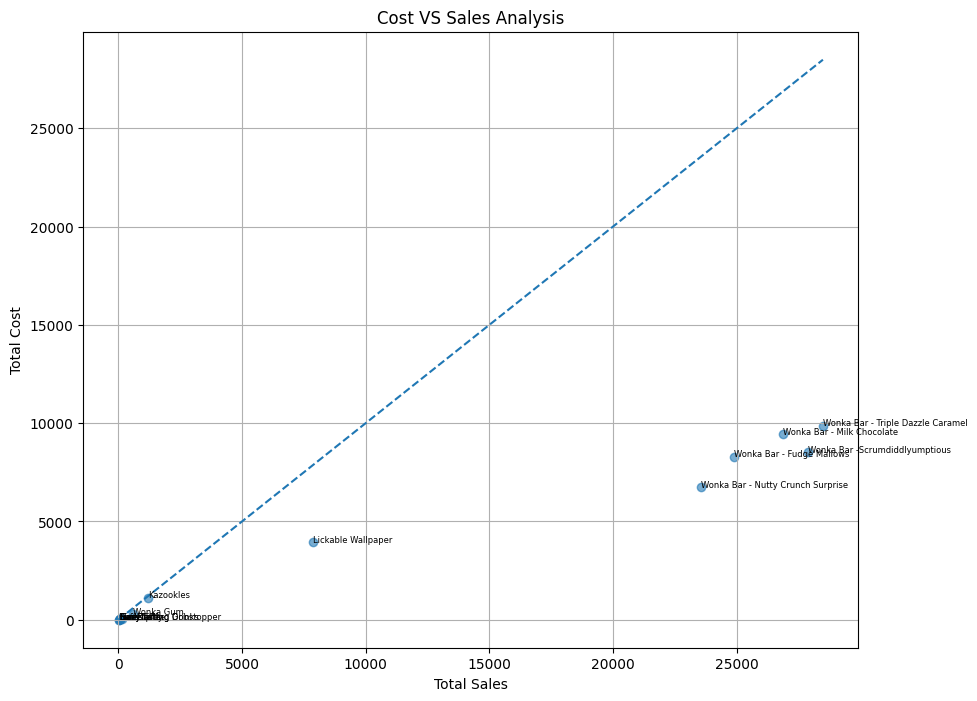

Product Cost Structure Summary
                         Product Name  Total_sales  Total_units  Total_cost  \
0              Everlasting Gobstopper       130.00           13       26.00   
1                Fizzy Lifting Drinks        78.75           21       31.50   
2                             Fun Dip        12.00            8        7.20   
3                         Hair Toffee        76.50           17       17.00   
4                           Kazookles      1205.75          371     1113.00   
5                         Laffy Taffy        53.73           27       20.25   
6                  Lickable Wallpaper      7860.00          393     3930.00   
7                               Nerds        15.00           10        8.00   
8                           Sweetarts        61.50           41       32.80   
9           Wonka Bar - Fudge Mallows     24890.40         6914     8296.80   
10         Wonka Bar - Milk Chocolate     26867.75         8267     9424.38   
11  Wonka Bar - Nutty

In [28]:
import matplotlib.pyplot as plt

# Group all transaction rows by product
product_cost_analysis = Data.groupby("Product Name").agg(
    Total_sales=("Sales","sum"),
    Total_units=("Units","sum"),
    Total_cost=("Cost","sum"),

).reset_index()
# Calculate  Total Profit 
product_cost_analysis["Total_profit"]=(product_cost_analysis["Total_sales"]-product_cost_analysis["Total_cost"])

# Calculate Gross Margin
product_cost_analysis["Gross_Margin_%"]=(product_cost_analysis["Total_profit"]/product_cost_analysis["Total_sales"]*100)

# Calculate Cost-to-Sales Ratio
product_cost_analysis["Cost_to_Sales_%"]=(product_cost_analysis["Total_cost"]/product_cost_analysis["Total_sales"]*100)

# Calculate Profit per Unit
product_cost_analysis["Profit_per_unit"]=(product_cost_analysis["Total_profit"]/product_cost_analysis["Total_units"])

# Remove invalid products
product_cost_analysis = product_cost_analysis[
    (product_cost_analysis["Total_sales"] > 0) &
    (product_cost_analysis["Total_units"] > 0)
].copy()


# Create Cost vs Sales Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(
    product_cost_analysis["Total_sales"],
    product_cost_analysis["Total_cost"],
    alpha=0.6
)

for _,row in product_cost_analysis.iterrows():
    plt.annotate(
        row["Product Name"],
        (row["Total_sales"],row["Total_cost"]),
        fontsize=6
    )

# Create the Cost = Sales reference line
maximum_value=max(
    product_cost_analysis["Total_sales"].max(),
    product_cost_analysis["Total_cost"].max()
)

plt.plot(
    [0,maximum_value],
    [0,maximum_value],
    linestyle="--"
)
plt.xlabel("Total Sales")
plt.ylabel("Total Cost")
plt.title("Cost VS Sales Analysis")
plt.grid(True)
plt.show()

# Cost-heavy, margin-poor products
cost_heavy_margin_poor=product_cost_analysis[
    (product_cost_analysis["Cost_to_Sales_%"]>=80) &
    (product_cost_analysis["Gross_Margin_%"]<=20)
]

# Identify Pricing Inefficiencies
sales_median=product_cost_analysis["Total_sales"].median()
margin_median=product_cost_analysis["Gross_Margin_%"].median()

Pricing_Inefficiencies=product_cost_analysis[
    (product_cost_analysis["Total_sales"] >= sales_median) &
    (product_cost_analysis["Gross_Margin_%"]<margin_median)
]

# Flag Products Needing Repricing
product_repricing=product_cost_analysis[
    product_cost_analysis["Gross_Margin_%"]<15
]

# Flag Products Needing Cost Renegotiation
Cost_Renegotiation=product_cost_analysis[
    product_cost_analysis["Cost_to_Sales_%"]>80
]

# Flag Products for Discontinuation Review
sales_median=product_cost_analysis["Total_sales"].median()
profit_median=product_cost_analysis["Total_profit"].median()

Discontinuation_Review=product_cost_analysis[
    (product_cost_analysis["Total_profit"]<profit_median) &
    (product_cost_analysis["Total_sales"]<sales_median)
]

# Identify Loss-Making Products Separately
loss_making_product=product_cost_analysis[
    (product_cost_analysis["Total_profit"]<0)
]

# Display complete product-level cost and profitability analysis.
print("Product Cost Structure Summary")
print(product_cost_analysis)

# Display cost-heavy and margin-poor products
print("\n Cost Heavy and Margin Poor Products :")
print(cost_heavy_margin_poor[
    ["Product Name","Total_sales","Total_cost","Total_profit","Gross_Margin_%","Cost_to_Sales_%","Profit_per_unit"]
])

# Display products with high sales but weak margin.
print("\nPricing Inefficiencies")
print(Pricing_Inefficiencies[
    ["Product Name","Total_sales","Total_profit","Gross_Margin_%"]
])

# Display products requiring selling-price review.
print("\nProducts Needing Repricing:")
print(product_repricing[
    ["Product Name","Total_sales","Total_profit","Gross_Margin_%"]
])

# Display products where cost is too high compared with sales.
print("\nProducts Needing Cost Renegotiation:")
print(Cost_Renegotiation[
    ["Product Name","Total_sales","Total_cost","Cost_to_Sales_%","Gross_Margin_%"]
])

# Display low-sales and low-profit products for review.
print("\nProducts for Discontinuation Review :")
print(Discontinuation_Review[
    ["Product Name","Total_sales","Total_profit","Gross_Margin_%"]

])

#  Display products where total cost is greater than total sales.
print("\nLoss Making Product")
print(loss_making_product[
    ["Product Name","Total_sales","Total_cost","Total_profit","Gross_Margin_%"]
])


# Key Performance Indicators (KPIs)

# KPI 1

In [14]:
# Gross Profit
Data["Gross_Profit"]=Data["Sales"]-Data["Cost"]

# Gross Margin %
Data["Gross_Margin_%"]=(Data["Gross_Profit"]/Data["Sales"]*100)

# KPI 2

In [15]:
Data["Profit_per_Unit_%"]=(Data["Gross_Profit"]/Data["Units"]*100)

# KPI 3

In [16]:
product_summary=Data.groupby("Product Name").agg(
    Total_sales=("Sales","sum")
).reset_index()

total_sales=product_summary["Total_sales"].sum()

product_summary["Revenue_Contribution_%"] = (
    product_summary["Total_sales"] /
    total_sales
) * 100

# KP1 4

In [17]:
# Calculate total company profit
total_profit = Data["Profit"].sum()

# Calculate Profit Contribution Percentage
Data["Profit_Contribution_%"] = (
    Data["Profit"] /
    total_profit
) * 100

# For product-level analysis:
product_summary = Data.groupby("Product Name").agg(
    Total_profit=("Profit", "sum")
).reset_index()

total_profit = product_summary["Total_profit"].sum()

product_summary["Profit_Contribution_%"] = (
    product_summary["Total_profit"] /
    total_profit
) * 100

# KP1 5

In [18]:
# Calculate monthly gross margin
monthly_margin = Data.groupby(
    ["Product Name", "Order Date"]
).agg(
    Gross_Margin=("Gross Margin", "mean")
).reset_index()

# Calculate Margin Volatility
margin_volatility = monthly_margin.groupby(
    "Product Name"
)["Gross_Margin"].std().reset_index()

margin_volatility.rename(
    columns={"Gross_Margin": "Margin_Volatility"},
    inplace=True
)
margin_volatility

,Product Name,Margin_Volatility
0,Everlasting gobstopper,0.000000e+00
1,Fizzy lifting drinks,0.000000e+00
2,Fun dip,0.000000e+00
3,Hair toffee,0.000000e+00
4,Kazookles,0.000000e+00
5,Laffy taffy,2.368476e-15
6,Lickable wallpaper,0.000000e+00
7,Nerds,0.000000e+00
8,Sweetarts,0.000000e+00
9,Wonka bar - fudge mallows,6.510644e-15


In [29]:
import pickle

with open("clean_data.pkl", "wb") as f:
    pickle.dump(Data_clean, f)